<a href="https://colab.research.google.com/github/ayesha-tubassum/EDA-project/blob/main/logistic_regression(loan_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# **Step 1: Data Loading Step**

In [ ]:
df = pd.read_csv("/content/bankloan.csv")
df.head()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
df.shape

(5000, 14)

In [ ]:
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP.Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal.Loan', 'Securities.Account',
       'CD.Account', 'Online', 'CreditCard'],
      dtype='object')

In [ ]:
df.dtypes

,0
ID,int64
Age,int64
Experience,int64
Income,int64
ZIP.Code,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal.Loan,int64


In [ ]:
df.describe()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


# **Step 2: Data Cleaning**

In [ ]:
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP.Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal.Loan,0


In [ ]:
df[df['Experience'] < 0]

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
89,90,25,-1,113,94303,4,2.30,3,0,0,0,0,0,1
226,227,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0
315,316,24,-2,51,90630,3,0.30,3,0,0,0,0,1,0
451,452,28,-2,48,94132,2,1.75,3,89,0,0,0,1,0
524,525,24,-1,75,93014,4,0.20,1,0,0,0,0,1,0
536,537,25,-1,43,92173,3,2.40,2,176,0,0,0,1,0
540,541,25,-1,109,94010,4,2.30,3,314,0,0,0,1,0
576,577,25,-1,48,92870,3,0.30,3,0,0,0,0,0,1
583,584,24,-1,38,95045,2,1.70,2,0,0,0,0,1,0
597,598,24,-2,125,92835,2,7.20,1,0,0,1,0,0,1


**Due to the negative values present in the experience column either we need to fix it or drop it, in case of high relation with age**  

In [ ]:
df['Experience'] = df['Experience'].abs()

In [ ]:
df.describe()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.134600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.415189,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,0.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [ ]:
df[['Age','Experience']].corr()

,Age,Experience
Age,1.000000,0.993991
Experience,0.993991,1.000000


**“Experience and Age are highly correlated, so to avoid multicollinearity I dropped Experience.”**

In [ ]:
df.drop(['ID', 'ZIP.Code', 'Experience'], axis=1, inplace=True)

In [ ]:
df.columns

Index(['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Personal.Loan', 'Securities.Account', 'CD.Account', 'Online',
       'CreditCard'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(13)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

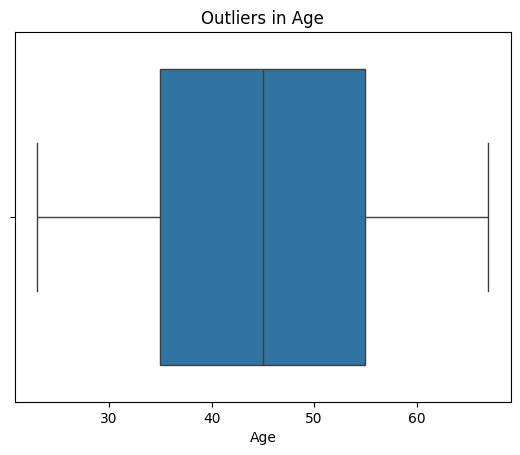

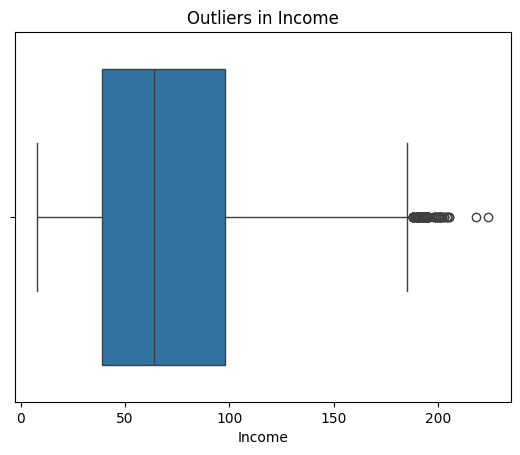

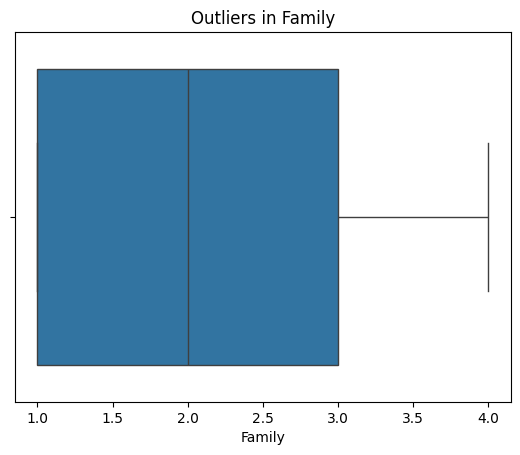

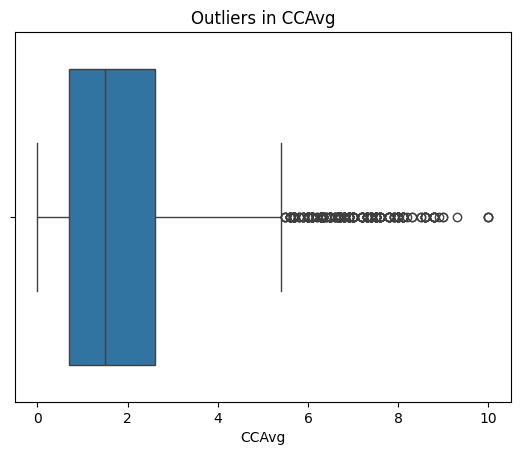

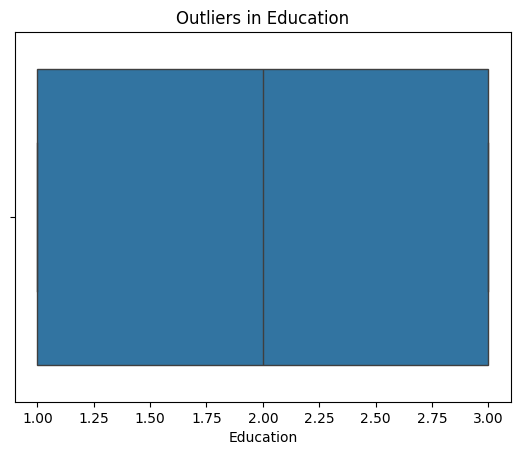

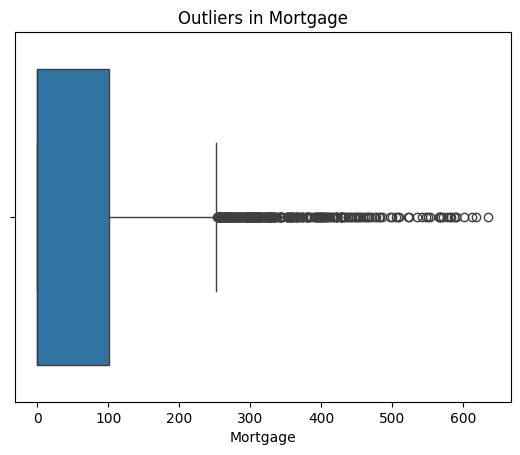

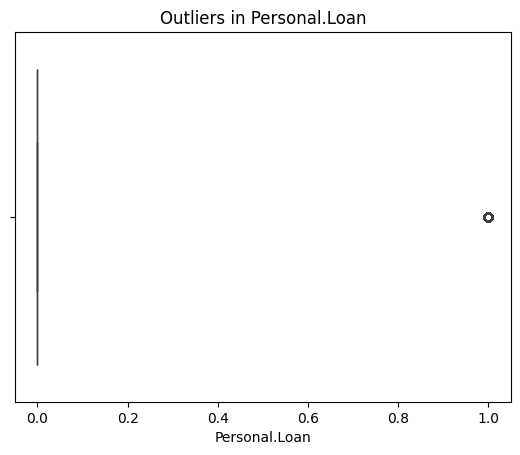

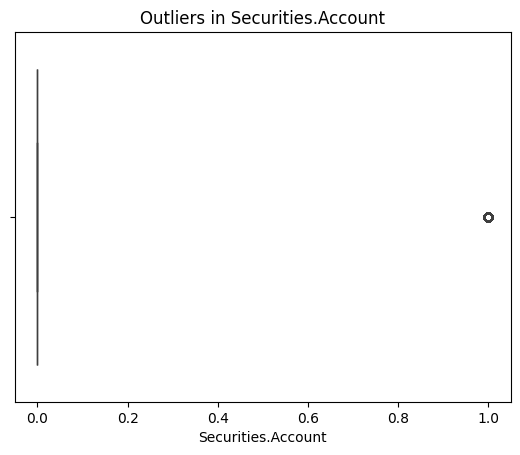

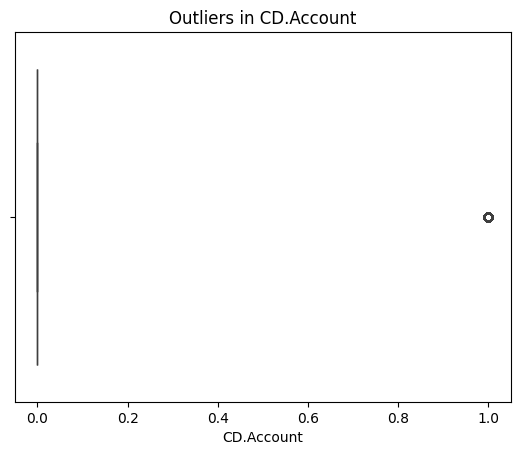

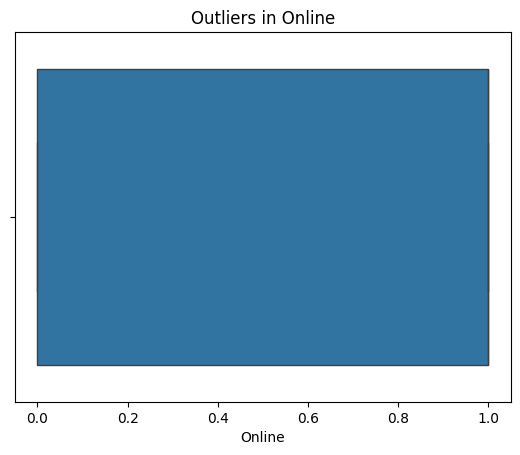

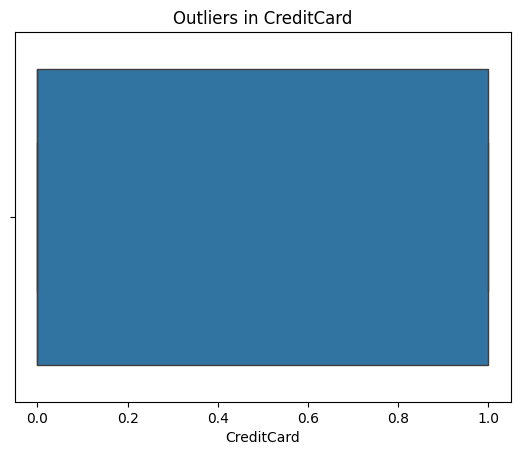

In [ ]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()

In [ ]:
for col in ['Income', 'CCAvg', 'Mortgage']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [ ]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]

    print(col, "remaining outliers:", len(outliers))

Income remaining outliers: 0
CCAvg remaining outliers: 0
Mortgage remaining outliers: 0


In [ ]:
df.shape

(4044, 11)

# **Step 3: Data Visualization**

In [ ]:
df['Personal.Loan'].value_counts()

,count
Personal.Loan,
0,3873
1,171


**uni_varient**

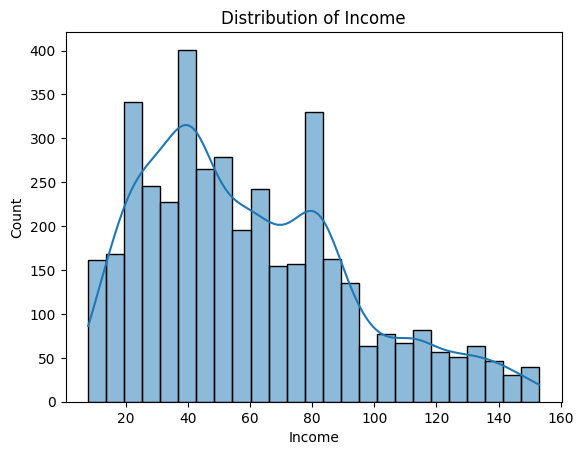

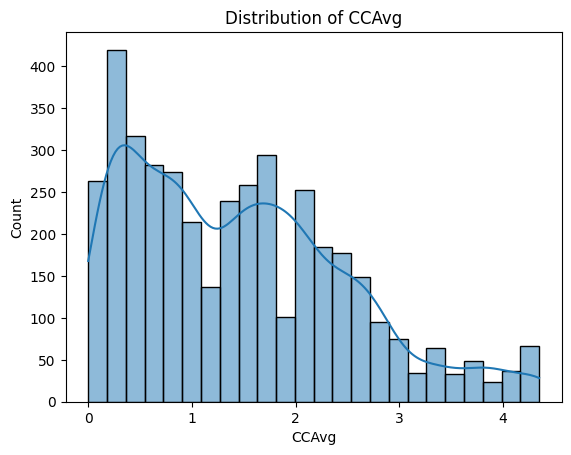

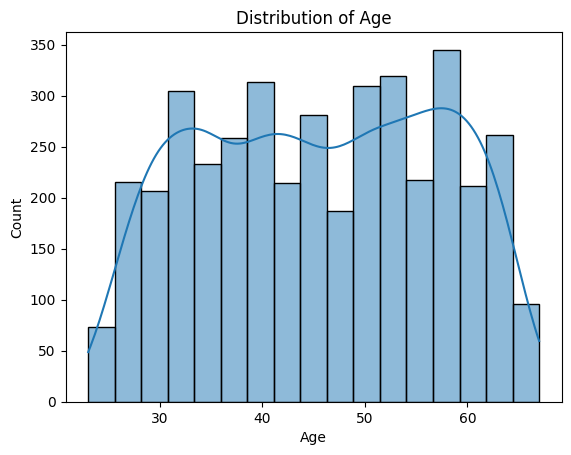

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Income', 'CCAvg', 'Age']

for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
df[cols].skew()

,0
Income,0.701314
CCAvg,0.681109
Age,-0.045672


In [ ]:
df['Income'] = np.log1p(df['Income'])
df['CCAvg'] = np.log1p(df['CCAvg'])

In [ ]:
df[['Income','CCAvg','Age']].skew()

,0
Income,-0.821280
CCAvg,-0.425435
Age,-0.045672


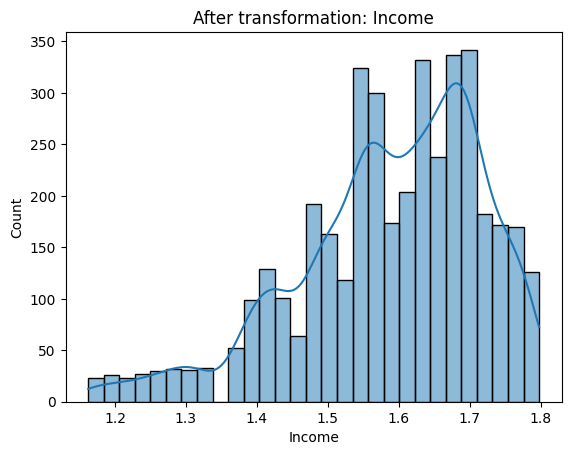

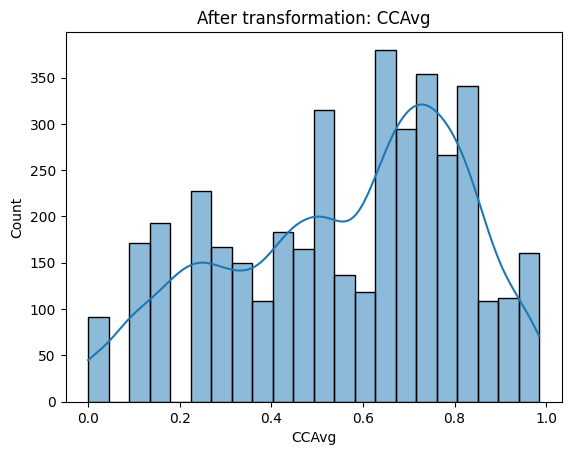

In [ ]:
for col in ['Income','CCAvg']:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"After transformation: {col}")
    plt.show()

**bivarient**

Income vs Loan

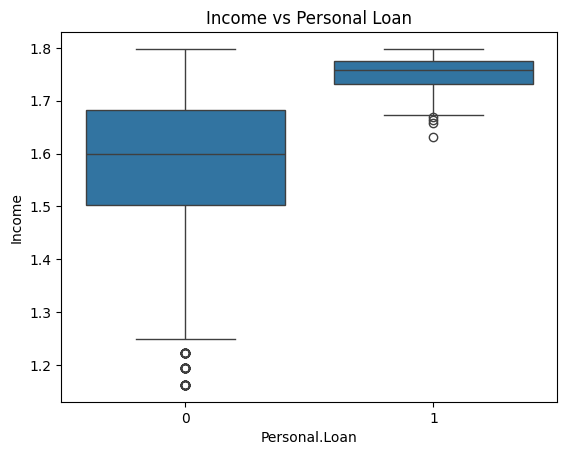

In [ ]:
sns.boxplot(x='Personal.Loan', y='Income', data=df)
plt.title("Income vs Personal Loan")
plt.show()

CCAvg vs Loan

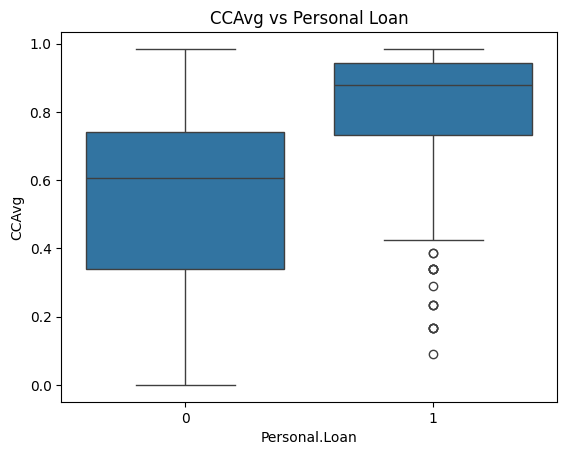

In [ ]:
sns.boxplot(x='Personal.Loan', y='CCAvg', data=df)
plt.title("CCAvg vs Personal Loan")
plt.show()

**Multivarient**

<Axes: xlabel='Income', ylabel='CCAvg'>

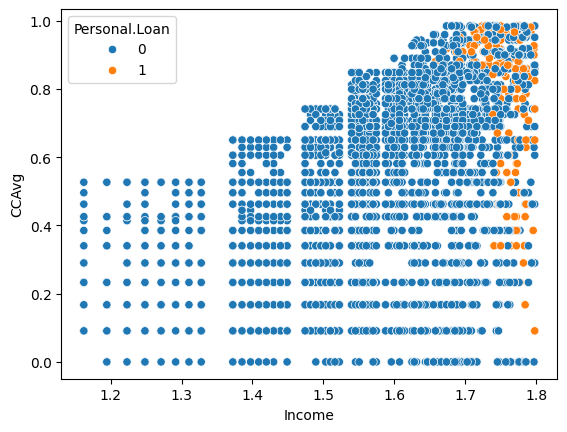

In [ ]:
sns.scatterplot(x='Income', y='CCAvg', hue='Personal.Loan', data=df)

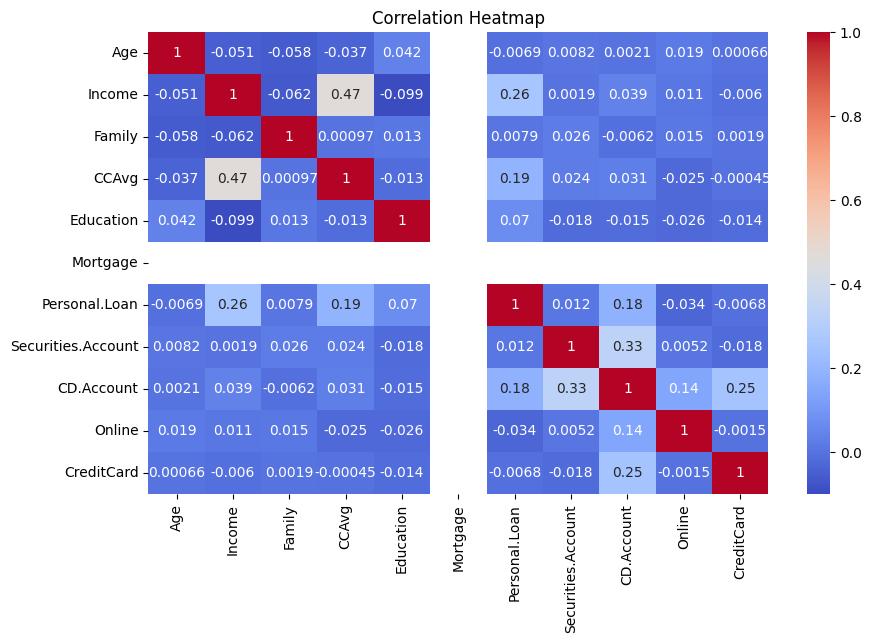

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()